In [153]:
import pandas as pd
df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df = pd.read_csv('./data/cytof.csv', index_col=0)

df_p0 = df[(df['simulationConditionId'].str.split('__').str[1]=='EGF') & (df['time'] == 0.0)].pivot_table(
    index='preequilibrationConditionId', columns='FEATURE_ID', values='measurement'
)
df_pt = df[(df['simulationConditionId'].str.split('__').str[1]=='EGF')].pivot_table(
    index='preequilibrationConditionId', columns='FEATURE_ID', values='measurement'
)
df_p = df_p0


df_tx.index = [f't{m}' for m in df_tx.index]
df_px.index = [f'p{m}' for m in df_px.index]

df = pd.concat([df_p, df_tx.T, df_px.T], axis=1)

In [130]:
df_pt

FEATURE_ID,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,...,p.S6,p.S6K,p.SMAD23,p.SRC,p.STAT1,p.STAT3,p.STAT5,p.p38,p.p53,p.p90RSK
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,,
c184A1,1.947373,3.052297,5.107729,2.394946,1.212711,2.515484,1.933219,2.444833,3.471868,2.475011,...,5.019947,2.198164,2.210417,1.843513,2.358390,2.441596,2.238641,2.292671,1.533452,3.001448
c184B5,1.957547,2.311961,5.958760,2.255738,0.884221,2.748893,2.553389,2.322446,3.593913,3.103394,...,4.692213,2.123429,2.106804,2.276190,2.506089,2.264365,2.493861,2.546793,1.781681,2.956444
cBT20,2.288187,2.228066,6.284131,2.814255,0.931947,2.182001,2.897757,2.525881,3.267079,4.466884,...,6.373105,2.455114,1.997308,2.599694,3.311281,2.267392,2.984866,3.088779,2.326697,4.541979
cBT474,1.828055,2.721244,6.125910,2.436720,0.998466,2.338102,2.587156,2.689460,2.548652,3.844061,...,6.004175,2.081220,1.713194,2.312714,3.204391,1.248218,2.542866,1.953173,1.861886,2.846647
cBT483,2.003603,2.018609,7.331352,2.674595,1.038493,1.658971,2.338835,2.040013,2.703117,3.922285,...,5.118272,2.174411,1.330951,2.325113,3.196862,2.551055,2.679557,2.452048,2.230727,3.726268
cBT549,3.562403,1.947643,8.340369,3.196664,0.709564,2.472409,2.759769,2.619844,3.421700,3.684110,...,5.952330,1.722007,1.981367,2.051729,3.004165,2.204693,2.587676,3.394835,3.960510,3.602317
cCAL148,2.744352,2.941269,6.918420,3.532479,1.095510,1.993400,3.637887,2.399182,2.564614,4.557559,...,5.255520,2.230486,1.473109,2.656290,2.846619,1.328775,1.881057,2.036479,2.337431,3.529777
cCAL51,4.260374,3.163223,7.745981,4.982450,1.130437,3.169486,3.208953,2.800299,3.244060,3.878464,...,6.990327,2.104462,1.970958,2.582669,2.944903,1.978573,1.910609,2.983276,2.299572,4.781743
cCAL851,2.817698,2.424568,6.499465,3.707231,0.723475,2.334459,2.640060,2.198448,2.999721,3.610976,...,5.966492,2.360752,1.708864,2.176828,3.170904,2.358000,2.539046,3.427446,2.188451,4.873720


Text(0, 0.5, 'p.p90RSK (0-60 min)')

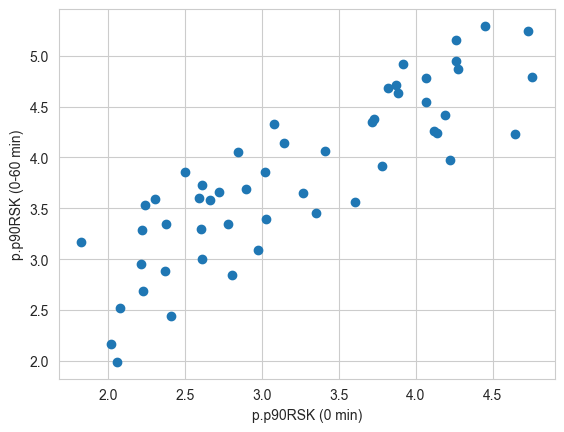

In [135]:
import matplotlib.pyplot as plt
plt.plot(df_p0['p.p90RSK'], df_pt['p.p90RSK'], 'o')
plt.xlabel('p.p90RSK (0 min)')
plt.ylabel('p.p90RSK (0-60 min)')

In [84]:
import numpy as np
def nancorr(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 30:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]

corrs ={
    m : {
    col: nancorr(df[m], df[col])
    for col in df.columns if col != m
    } for m in ('p.p90RSK', 'p.ERK', 'p.p38')
}

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [85]:
corrs = pd.DataFrame(corrs)
corrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.141148,0.030023,0.252274
GAPDH,0.194440,0.157299,0.191839
IdU,0.105179,0.102308,0.155013
Ki.67,0.064921,-0.017388,0.091337
b.CATENIN,-0.047425,0.010789,0.023106
...,...,...,...
pZWINT,0.255154,0.166513,0.266890
pZYG11B,-0.185070,-0.201639,0.064313
pZYX,0.274695,0.202250,0.288555
pZZEF1,-0.027400,-0.102347,-0.232834


In [86]:
corrs.sort_values('p.p90RSK', ascending=True)

,p.p90RSK,p.ERK,p.p38
pFAM186B,-0.620548,-0.456559,-0.369858
pSLC34A2,-0.549064,-0.521394,-0.410079
tYWHAG,-0.527365,-0.532367,-0.343740
pNAA16,-0.526626,-0.272386,-0.274680
tCCDC78,-0.520563,-0.434205,-0.569229
...,...,...,...
pZNF652,NaN,NaN,NaN
pZNF664,NaN,NaN,NaN
pZNF703,NaN,NaN,NaN
pZNRF1,NaN,NaN,NaN


In [87]:
df[corrs.index[:20]]

,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,p.BTK,p.CREB,p.ERK,p.FAK,p.GSK3b,p.H3,p.HER2,p.JNK,p.MAP2K3,p.MAPKAPK2
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,
c184A1,1.899881,2.671202,5.155996,2.293709,1.199649,2.442617,2.145631,2.308309,3.062391,2.107731,2.407913,0.760127,2.610448,1.853695,1.866942,2.730879,4.166056,1.675893,1.405707,1.636638
c184B5,2.229413,1.863406,6.515773,2.303428,0.787387,2.514049,2.174009,2.095415,3.504545,2.661403,2.718669,0.684448,2.303940,1.895044,1.796000,2.512144,4.378879,1.541652,1.305845,1.488424
cBT20,2.371916,2.203818,6.286955,2.892897,1.070486,2.322998,3.069261,2.654906,3.025359,4.151704,2.636486,1.040243,3.805443,2.531443,4.027275,2.708236,4.475806,1.662586,1.691324,2.398797
cBT474,1.928122,3.061742,6.299717,2.596004,1.157233,2.495332,2.847608,2.891991,2.539543,3.945938,2.816118,0.959422,3.089931,2.145890,4.168093,2.413827,5.086383,2.025342,1.566893,2.646992
cBT483,2.112961,2.071960,7.334562,2.852788,1.066758,1.770263,2.647414,2.049901,2.713179,3.295576,2.603112,0.591693,2.941606,1.544751,2.888916,1.922479,NaN,1.357219,1.360084,1.898411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cMDAMB436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cZR75B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC2157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df[corrs.index[:20]]

,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,p.BTK,p.CREB,p.ERK,p.FAK,p.GSK3b,p.H3,p.HER2,p.JNK,p.MAP2K3,p.MAPKAPK2
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,
c184A1,1.899881,2.671202,5.155996,2.293709,1.199649,2.442617,2.145631,2.308309,3.062391,2.107731,2.407913,0.760127,2.610448,1.853695,1.866942,2.730879,4.166056,1.675893,1.405707,1.636638
c184B5,2.229413,1.863406,6.515773,2.303428,0.787387,2.514049,2.174009,2.095415,3.504545,2.661403,2.718669,0.684448,2.303940,1.895044,1.796000,2.512144,4.378879,1.541652,1.305845,1.488424
cBT20,2.371916,2.203818,6.286955,2.892897,1.070486,2.322998,3.069261,2.654906,3.025359,4.151704,2.636486,1.040243,3.805443,2.531443,4.027275,2.708236,4.475806,1.662586,1.691324,2.398797
cBT474,1.928122,3.061742,6.299717,2.596004,1.157233,2.495332,2.847608,2.891991,2.539543,3.945938,2.816118,0.959422,3.089931,2.145890,4.168093,2.413827,5.086383,2.025342,1.566893,2.646992
cBT483,2.112961,2.071960,7.334562,2.852788,1.066758,1.770263,2.647414,2.049901,2.713179,3.295576,2.603112,0.591693,2.941606,1.544751,2.888916,1.922479,NaN,1.357219,1.360084,1.898411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cMDAMB436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cZR75B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC2157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
corrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.141148,0.030023,0.252274
GAPDH,0.194440,0.157299,0.191839
IdU,0.105179,0.102308,0.155013
Ki.67,0.064921,-0.017388,0.091337
b.CATENIN,-0.047425,0.010789,0.023106
...,...,...,...
pZWINT,0.255154,0.166513,0.266890
pZYG11B,-0.185070,-0.201639,0.064313
pZYX,0.274695,0.202250,0.288555
pZZEF1,-0.027400,-0.102347,-0.232834


In [90]:
from scipy import stats
def nancorr_p(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 30:
        return np.nan
    return stats.pearsonr(a[mask], b[mask])[1]

In [91]:
nancorr_p(df['p.p90RSK'], df['pRAB12'])

np.float64(0.00039538092546689504)

In [92]:
df_p.columns

Index(['CyclinB', 'GAPDH', 'IdU', 'Ki.67', 'b.CATENIN', 'cleavedCas',
       'p.4EBP1', 'p.AKT.Thr308.', 'p.AMPK', 'p.Akt.Ser473.', 'p.BTK',
       'p.CREB', 'p.ERK', 'p.FAK', 'p.GSK3b', 'p.H3', 'p.HER2', 'p.JNK',
       'p.MAP2K3', 'p.MAPKAPK2', 'p.MEK', 'p.MKK3.MKK6', 'p.MKK4', 'p.NFkB',
       'p.PDPK1', 'p.PLCg2', 'p.RB', 'p.S6', 'p.S6K', 'p.SMAD23', 'p.SRC',
       'p.STAT1', 'p.STAT3', 'p.STAT5', 'p.p38', 'p.p53', 'p.p90RSK'],
      dtype='object', name='FEATURE_ID')

In [93]:
pcorrs ={
    m : {
    col: nancorr_p(df[m], df[col])
    for col in df.columns if col != m
    } for m in ('p.p90RSK', 'p.ERK', 'p.p38')
}

/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_17998/196763736.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return stats.pearsonr(a[mask], b[mask])[1]


In [94]:
pcorrs = pd.DataFrame(pcorrs)
pcorrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.318231,8.326652e-01,7.119120e-02
GAPDH,0.167197,2.654194e-01,1.730600e-01
IdU,0.458039,4.704705e-01,2.725141e-01
Ki.67,0.647489,9.026225e-01,5.195890e-01
b.CATENIN,0.738482,9.394906e-01,8.708423e-01
...,...,...,...
pZWINT,0.076830,2.528277e-01,6.377024e-02
pZYG11B,0.202991,1.647260e-01,6.606450e-01
pZYX,0.048747,1.504626e-01,3.802613e-02
pZZEF1,0.847103,4.702968e-01,9.669496e-02


<Axes: >

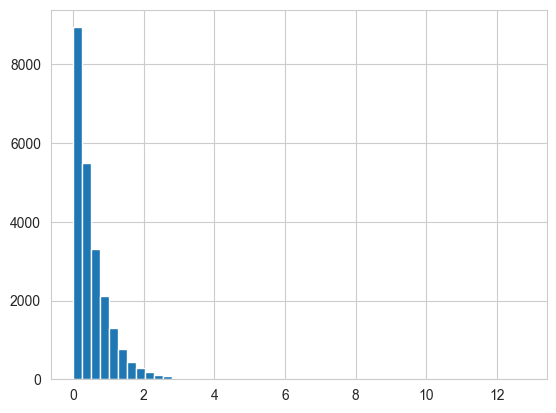

In [112]:
from scipy.stats import false_discovery_control
from statsmodels.stats.multitest import multipletests
pcorrs['p.p90RSK'].apply(lambda p: -np.log10(p)).hist(bins=50)

In [122]:
marker = 'p.p90RSK'
df_fin = pcorrs[marker].loc[np.isfinite(pcorrs[marker].values) & [not m.startswith('p.') and m.startswith(('t', 'p')) for m in pcorrs.index]]
pval = pd.Series(multipletests(df_fin, method='bonferroni')[1], index=df_fin.index)
pval.sort_values()

tMAP3K8     0.148068
pACTN2      0.444426
pFAM186B    0.447945
pPLS1       0.916007
tA1BG       1.000000
              ...   
tLRIG3      1.000000
tLRIG2      1.000000
tLRIG1      1.000000
tLRGUK      1.000000
pZZEF1      1.000000
Length: 23078, dtype: float64

In [118]:
?multipletests

In [104]:
pcorrs[marker]

CyclinB      0.318231
GAPDH        0.167197
IdU          0.458039
Ki.67        0.647489
b.CATENIN    0.738482
               ...   
pZWINT       0.076830
pZYG11B      0.202991
pZYX         0.048747
pZZEF1       0.847103
p.p90RSK          NaN
Name: p.p90RSK, Length: 24476, dtype: float64

In [97]:
df_fin.index

Index(['tA1BG', 'tA2M', 'tA2ML1', 'tA4GALT', 'tAAAS', 'tAACS', 'tAADAC',
       'tAADACL3', 'tAADAT', 'tAAGAB',
       ...
       'pZNRF2', 'pZPR1', 'pZRANB2', 'pZSWIM8', 'pZW10', 'pZWILCH', 'pZWINT',
       'pZYG11B', 'pZYX', 'pZZEF1'],
      dtype='object', length=23078)

In [98]:
import gseapy as gp
sets = ['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human']
gl_t = [g[1:] for g in pval[pval < 0.05].index if g.startswith('t')]
bg_t = [g[1:] for g in pval.index if g.startswith('t')]
enr_tx = gp.enrichr(
    gene_list=gl_t,
    gene_sets=sets,
    organism='human',
    background=bg_t,
    outdir=None,
)
enr_tx.results.sort_values('Adjusted P-value', ascending=True)

ValueError: Gene list cannot be empty

In [70]:
import gseapy as gp
sets = ['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human']
gl_p = [g[1:] for g in pval[pval < 0.05].index if g.startswith('p')]
bg_p = [g[1:] for g in pval.index if g.startswith('p')]
enr_px = gp.enrichr(
    gene_list=gl_p,
    gene_sets=sets,
    organism='human',
    background=bg_p,
    outdir=None,
)
enr_px.results.sort_values('Adjusted P-value', ascending=True)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
715,Reactome_Pathways_2024,Formation of ATP by Chemiosmotic Coupling,1.071186e-08,0.000002,0,0,106.911765,1962.035515,ATP5F1A;ATP5F1B;ATP5PB;ATP5F1D;ATP5MG
900,WikiPathway_2023_Human,Oxidative Phosphorylation WP623,2.264025e-07,0.000012,0,0,29.600000,452.908162,ATP5F1A;ATP5F1B;NDUFB10;ATP5PB;ATP5F1D;ATP5MG
716,Reactome_Pathways_2024,Cristae Formation,4.084299e-07,0.000038,0,0,43.649733,642.128842,ATP5F1A;ATP5F1B;ATP5PB;ATP5MG;ATP5F1D
464,KEGG_2021_Human,Oxidative phosphorylation,1.015647e-06,0.000058,0,0,16.255388,224.324109,ATP5F1A;ATP5F1B;NDUFB10;ATP5PB;ATP5F1D;ATP5MG;...
312,GO_Cellular_Component_2025,Mitochondrial Inner Membrane (GO:0005743),1.038568e-06,0.000087,0,0,8.244727,113.593106,MRPL20;MRPL3;ATP5F1A;ATP5F1B;NDUFB10;ATP5PB;MR...
...,...,...,...,...,...,...,...,...,...
311,GO_Biological_Process_2025,Regulation of DNA-templated Transcription (GO:...,9.718650e-01,0.971865,0,0,0.274069,0.007821,MAZ
896,Reactome_Pathways_2024,RNA Polymerase II Transcription,9.664782e-01,0.978752,0,0,0.288896,0.009850,STUB1
897,Reactome_Pathways_2024,Developmental Biology,9.681712e-01,0.978752,0,0,0.284353,0.009198,RPS6KA3
899,Reactome_Pathways_2024,Post-translational Protein Modification,9.903288e-01,0.990329,0,0,0.207952,0.002021,RAB12


/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


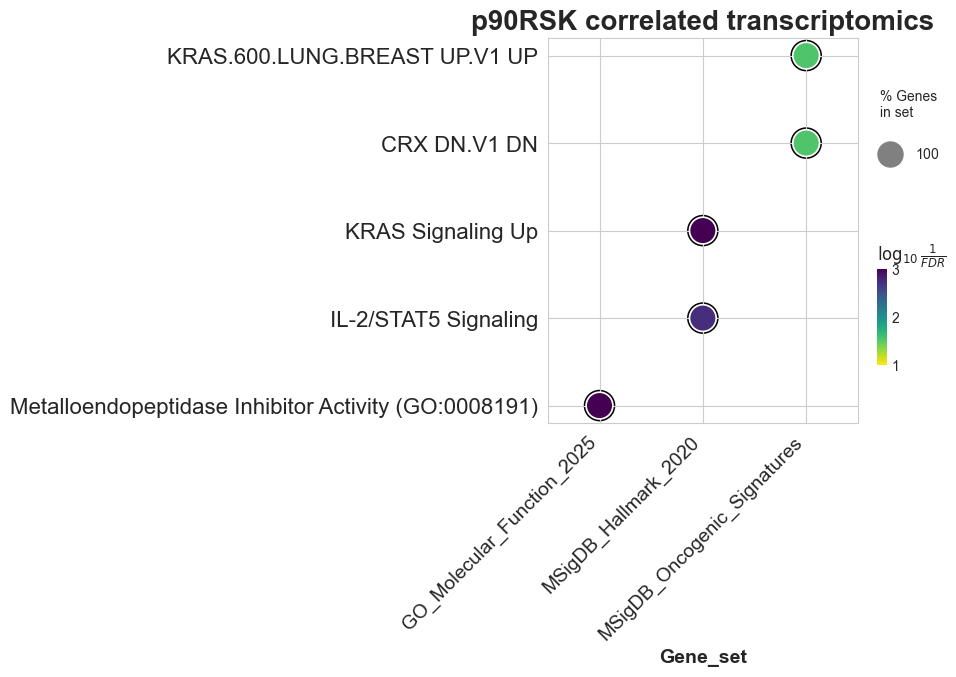

In [71]:
ax = gp.dotplot(
    enr_tx.results,
    column="Adjusted P-value",
    x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
    size=3,
    figsize=(5,5),
    title = "p90RSK correlated transcriptomics",
    xticklabels_rot=45, # rotate xtick labels
    show_ring=True, # set to False to remove outer ring
    marker='o',
)

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


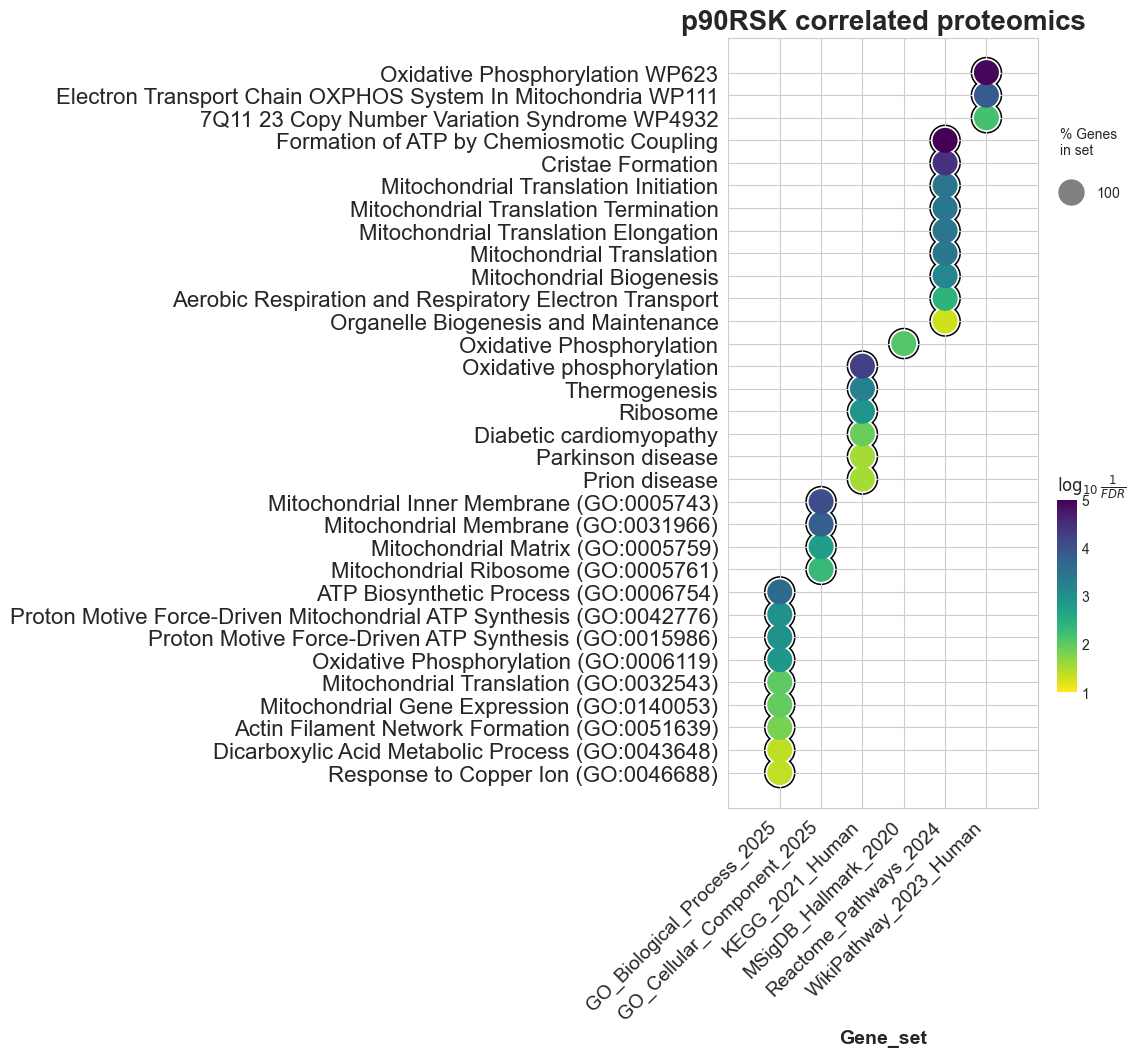

In [72]:
ax = gp.dotplot(
    enr_px.results,
    column="Adjusted P-value",
    x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
    size=3,
    figsize=(5,10),
    title = "p90RSK correlated proteomics",
    xticklabels_rot=45, # rotate xtick labels
    show_ring=True, # set to False to remove outer ring
    marker='o',
)

In [50]:
gl_t

['ACTBL2',
 'ATP11B',
 'CCDC78',
 'CCDC87',
 'CDC14B',
 'CERS6',
 'CHST8',
 'CIB2',
 'CLIP4',
 'CNN3',
 'CNPPD1',
 'COL18A1',
 'CP',
 'CTSS',
 'DNAJC14',
 'EME2',
 'ETS1',
 'ETV4',
 'FAHD1',
 'FPGT',
 'GHR',
 'GJA5',
 'GLIPR2',
 'GPRC5B',
 'GPRIN2',
 'HABP4',
 'HLA.DMB',
 'KIAA1257',
 'LCMT2',
 'LIF',
 'MAP3K8',
 'MRPS33',
 'NAB1',
 'PARD6G',
 'PAX6',
 'PIGR',
 'PLS3',
 'PPP1R10',
 'PXDC1',
 'QSOX1',
 'RARRES1',
 'RCAN1',
 'RECK',
 'RNF41',
 'S100A5',
 'SIGLEC15',
 'SMOX',
 'TBC1D1',
 'TBCA',
 'TGM2',
 'TIMP2',
 'TMEM63C',
 'TRIAP1',
 'TSPAN2',
 'UACA',
 'UBASH3B',
 'ZSCAN32']

In [65]:
import mygene

def symbols_to_uniprot(symbols):
    """
    Convert HGNC gene symbols (e.g. EGFR) to UniProt accessions.
    Returns a dict: {symbol: [uniprot IDs] or None}
    """
    mg = mygene.MyGeneInfo()
    res = mg.querymany(
        symbols,
        scopes="symbol",                # search by HGNC gene symbol
        fields="uniprot.Swiss-Prot",
        species="human"                 # restrict to human
    )

    mapping = {}
    for r in res:
        sym = r["query"]
        if "notfound" in r and r["notfound"]:
            mapping[sym] = None
        else:
            ids = []
            uniprot_field = r.get("uniprot", {})
            if isinstance(uniprot_field, dict):
                # could have 'Swiss-Prot' and/or 'TrEMBL', which may be str or list
                for sub in ["Swiss-Prot", "TrEMBL"]:
                    val = uniprot_field.get(sub)
                    if val:
                        ids.extend(val if isinstance(val, list) else [val])
            elif isinstance(uniprot_field, str):
                ids.append(uniprot_field)
            mapping[sym] = ids if ids else None
    return mapping

INFO:biothings.client:querying 1-1 ...
INFO:biothings.client:Finished.


['P00533']

In [84]:
import omnipath
op = omnipath.interactions.PostTranslational()
df_ptm = op.get()
erbb_upids = [upid for upids in symbols_to_uniprot(['EGFR', 'ERBB2']).values() for upid in upids if upids]
erbb_upids

INFO:biothings.client:querying 1-2 ...
INFO:biothings.client:Finished.


['P00533', 'P04626']

In [72]:
upid_t = symbols_to_uniprot(gl_t)
upid_p = symbols_to_uniprot(gl_p)

INFO:biothings.client:querying 1-57 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-53 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [74]:
upid_p.values()

dict_values([None, None, None, None, None, None, None, None, None, None, ['Q52LW3'], ['P25705'], ['P06576'], ['P30049'], ['O75964'], ['P24539'], ['Q8N8Y2'], ['Q86X02'], ['Q14011'], ['Q9NUL7'], ['Q969X5'], ['Q6P587'], None, ['P48507'], ['Q9UKN8'], ['Q9BW19'], ['P56270'], ['Q9NX20'], ['Q9H0U6'], ['P49406'], ['Q9BYC9'], ['Q9P0M9'], ['P09001'], ['Q9BQC6'], ['Q9BYD2'], ['P80297'], ['Q9UBB6'], ['O14777'], ['O96000'], ['Q9UNZ2'], ['Q9BQG2'], ['Q9ULD0'], ['Q14651'], ['P13797'], ['Q6IQ22'], ['Q9Y3L5'], ['Q8IXI1'], ['P51812'], ['Q14108'], ['Q9UNE7'], ['Q03519'], ['Q96A57'], ['P18206']])

In [85]:
df_ptm[
    (df_ptm['target'].isin(erbb_upids))
    &
    (df_ptm['source'].isin([upid for upids in upid_t.values() if upids for upid in upids]))
]

,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped
97123,Q9H4P4,P00533,True,False,True,True,False,True,0,NaN,Wang,1,1,None,None
111817,P43268,P04626,True,False,True,True,False,True,0,NaN,Wang,1,1,None,None
119854,P21980,P00533,True,True,False,True,True,False,0,NaN,Wang,1,1,None,None
127265,Q9H4P4,P04626,True,True,False,True,True,False,0,NaN,Wang,1,1,None,None


In [86]:
df_ptm[
    (df_ptm['target'].isin(erbb_upids))
    &
    (df_ptm['source'].isin([upid for upids in upid_p.values() if upids for upid in upids]))
]

,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped
31509,Q9UNE7,P04626,True,False,True,True,False,True,8,Cellinker:21710689;HINT:12239347;HINT:12574167...,Cellinker;HINT;HPRD;SIGNOR,4,4,5,12239347;12574167;17239458;17875712;21710689


In [52]:
cp = omnipath.requests.Complexes()
egfr_cp = set([gs for gsl in cp.complex_genes('EGFR')['components_genesymbols'].str.split('_').tolist() for gs in gsl])

In [56]:
egfr_t = [g for g in egfr_cp if g in gl_t]
egfr_t

['ETS1', 'MAP3K8', 'GHR', 'LIF']

In [57]:
egfr_p = [g for g in egfr_cp if g in gl_p]
egfr_p

['STUB1', 'ATP5PB', 'ATP5F1B', 'ATP5F1A']

In [58]:
cp.complex_genes('EGFR')[cp.complex_genes('EGFR').apply(lambda x: any(g in x['components_genesymbols'].split('_') for g in gl_t), axis=1)]

,name,components,components_genesymbols,stoichiometry,sources,references,identifiers,n_sources,n_primary_sources,n_references,references_stripped
20,JAK-STAT-Core,O60674_O75462_P00533_P01236_P01241_P01562_P015...,CNTF_CNTFR_CRLF1_CRLF2_CSF1_CSF2_CSF2RA_CSF3_C...,1:1:1:1:1:2:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:...,Compleat,None,Compleat:HC2503,1,1,None,None
27,EGF-Core,O14511_O14654_O14733_O15264_O43283_O43318_O755...,AREG_ATF1_ATF2_BRAF_BTC_CDC42_CREB1_CRK_DDIT3_...,1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:...,Compleat,None,Compleat:HC2002,1,1,None,None


In [59]:
cp.complex_genes('EGFR')[cp.complex_genes('EGFR').apply(lambda x: any(g in x['components_genesymbols'].split('_') for g in gl_p), axis=1)]

,name,components,components_genesymbols,stoichiometry,sources,references,identifiers,n_sources,n_primary_sources,n_references,references_stripped
16,None,P00533_P07900_P08238_P0DMV9_P11142_P25685_P319...,CDC37_DNAJB1_EGFR_HSP90AA1_HSP90AB1_HSPA1B_HSP...,1:1:1:1:1:1:1:1:1:1:1:1:1:1:1,Compleat;NetworkBlast,None,Compleat:HC6704,2,2,None,None
69,None,O75947_P00533_P06576_P24539_P25705_P36542_P480...,ATP5F1A_ATP5F1B_ATP5F1C_ATP5F1E_ATP5MF_ATP5PB_...,1:1:1:1:1:1:1:1:1:1,Compleat;NetworkBlast,None,Compleat:HC9763,2,2,None,None


In [80]:
df_px.T[[f'p{g}' for g in gl_p]].var().sort_values(ascending=False)

pPLS3        2.697793
pMT1X        2.082605
pTAP2        1.942955
pCDR2L       1.785163
pARHGAP29    1.714790
pNUDT12      1.409290
pRPS6KA3     1.215718
pGCLM        1.200741
pRAB12       1.134064
pFLJ45252    1.019091
pPLS1        0.973937
pVCL         0.971932
pMAZ         0.804011
pSTUB1       0.765960
pCIRBP       0.729863
pSCARB2      0.720757
pFAHD1       0.629359
pKIFC1       0.613403
pNSFL1C      0.606656
pRAP2C       0.598261
pGTF3C4      0.552054
pDDX28       0.547625
pRHOT2       0.535929
pATP5F1B     0.485954
pNCDN        0.474234
pATP5PB      0.463507
pATP5MG      0.455645
pOGDHL       0.443913
pTMEM230     0.442833
pNDUFB10     0.410383
pATP5F1A     0.405650
pMRPL20      0.287410
pATP6V0D2    0.262804
pATP5F1D     0.250228
pMRPL9       0.233275
pMRPL19      0.226756
pMRPL18      0.213069
pMRPL3       0.203800
pMRPL27      0.173537
dtype: float64

In [82]:
df_tx.T[[f't{g}' for g in gl_t]].var().sort_values(ascending=False)

tRARRES1     17.941617
tCP          15.050110
tETS1        14.716336
tTGM2        11.138865
tPLS3         9.977637
tCLIP4        9.341540
tCTSS         9.304970
tUBASH3B      9.108405
tGJA5         8.938708
tGHR          8.235306
tLIF          6.399666
tPIGR         6.220907
tGPRIN2       6.216255
tHLA.DMB      6.036319
tPXDC1        5.863710
tTSPAN2       5.820314
tETV4         5.757492
tGPRC5B       5.479941
tTIMP2        5.420871
tCIB2         5.208761
tGLIPR2       5.104147
tCOL18A1      4.696799
tRECK         4.457947
tSMOX         3.987123
tKIAA1257     3.668719
tCCDC78       3.128604
tATP11B       2.984957
tCDC14B       2.874146
tS100A5       2.860730
tSIGLEC15     2.558074
tTBC1D1       2.278971
tPARD6G       2.173998
tHABP4        1.785749
tACTBL2       1.550047
tMAP3K8       1.469622
tNAB1         1.340490
tEME2         1.303342
tUACA         1.281862
tCERS6        1.202571
tCCDC87       1.181373
tLCMT2        0.859997
tTBCA         0.494502
tFAHD1        0.461838
tFPGT      

In [181]:
sub_df = df.loc[:,df.isna().sum(axis=0) == 0,:]

IndexingError: Too many indexers

In [183]:
df.isna().sum(axis=0)==0

CyclinB      False
GAPDH        False
IdU          False
Ki.67        False
b.CATENIN    False
             ...  
pZWINT       False
pZYG11B      False
pZYX          True
pZZEF1        True
class         True
Length: 24477, dtype: bool

In [178]:
sub_df.shape

(0, 24477)

In [172]:
df_de = (sub_df[sub_df['p.p90RSK'] > sub_df['p.p90RSK'].median()].mean() - sub_df[sub_df['p.p90RSK'] <= df['p.p90RSK'].median()].mean())

In [176]:
df.shape

(67, 24477)

In [173]:
df_de.sort_values(ascending=False)

CyclinB     NaN
GAPDH       NaN
IdU         NaN
Ki.67       NaN
b.CATENIN   NaN
             ..
pZWINT      NaN
pZYG11B     NaN
pZYX        NaN
pZZEF1      NaN
class       NaN
Length: 24477, dtype: float64

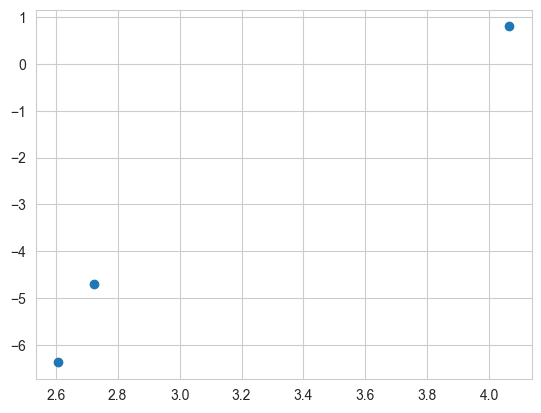

In [170]:
plt.scatter(df['p.p90RSK'], df['pPDPN'])